<a id="gibbs-sampling"></a>

# Combine NUTS and Gibbs

Sample the same regression posterior as in
{doc}`01c-transform`, now updating the coefficients with NUTS and the variance
with an exact Gibbs step. The prior and likelihood stay the same; only the
sampling strategy changes.

## Build the model

This repeats the setup so the tutorial runs on its own.

In [1]:
import jax.numpy as jnp
import numpy as np
import pandas as pd
import tensorflow_probability.substrates.jax.bijectors as tfb
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl

# Simulate regression observations.
rng = np.random.default_rng(42)
n = 500
true_beta = np.array([1.0, 2.0])
true_sigma = 1.0
x = rng.uniform(size=n)
X_mat = np.column_stack([np.ones(n), x])
y_vec = X_mat @ true_beta + rng.normal(scale=true_sigma, size=n)

# Define the priors.
beta = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, 0.0, 5.0),
    name="beta",
)
sigma_sq = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.InverseGamma, concentration=3.0, scale=2.0),
    name="sigma_sq",
)

# Connect the parameters to the observations.
sigma = lsl.Var.new_calc(jnp.sqrt, sigma_sq, name="sigma")
X = lsl.Var.new_obs(X_mat, name="X")
mu = lsl.Var.new_calc(jnp.dot, X, beta, name="mu")
y = lsl.Var.new_obs(
    y_vec,
    dist=lsl.Dist(tfd.Normal, mu, sigma),
    name="y",
)
model = lsl.Model(y)

The inverse-gamma prior has concentration $a=3$ and scale $b=2$.
These are fixed hyperparameters, not parameters to be sampled.

<a id="using-a-gibbs-kernel"></a>

## Define the Gibbs update

For coefficients $\boldsymbol\beta$, the residual sum of squares is
$S=\sum_i(y_i-\mathbf{x}_i^\top\boldsymbol\beta)^2$.
Because the coefficient prior is independent of the variance, its full
conditional is

$$
\sigma^2 \mid \boldsymbol\beta,\mathbf y
\sim \operatorname{InverseGamma}\left(a+\frac{n}{2},\ b+\frac{S}{2}\right).
$$

Goose does not derive this distribution. Supply a transition function that
uses the **current** state and draws from it:

In [2]:
def draw_sigma_sq(prng_key, model_state):
    pos = model.extract_position(["y", "mu"], model_state)
    resid = pos["y"] - pos["mu"]

    conditional = tfd.InverseGamma(
        concentration=3.0 + resid.size / 2,
        scale=2.0 + jnp.sum(resid**2) / 2,
    )
    return {"sigma_sq": conditional.sample(seed=prng_key)}

The prior's fixed hyperparameters may be constants here. The mean must be
read from `model_state` so the update uses the current coefficients, rather
than their initial values. Use the supplied random key, JAX-compatible
calculations, and a position dictionary with the sampled variable's name.

## Choose the update order

In [3]:
model.vars["beta"].inference = gs.MCMCSpec(
    gs.NUTSKernel,
    order=1,
    jitter_dist=tfd.Normal(0.0, 0.2),
)
model.vars["sigma_sq"].inference = gs.MCMCSpec(
    gs.GibbsKernel.with_transition_fn(draw_sigma_sq),
    order=2,
    jitter_dist=tfd.LogNormal(0.0, 0.1),
    jitter_method="multiplicative",
)

Within each iteration:

| Step | Update | Values used |
| --- | --- | --- |
| 1 | NUTS proposes both coefficients together. | The current variance. |
| 2 | Gibbs draws a new variance. | The newly updated coefficients. |
| 3 | Goose stores the iteration. | Both updated blocks. |

The positive multiplicative jitter keeps the initial variance on its support.
The Gibbs kernel has no tuning, but the NUTS kernel still needs adaptation.

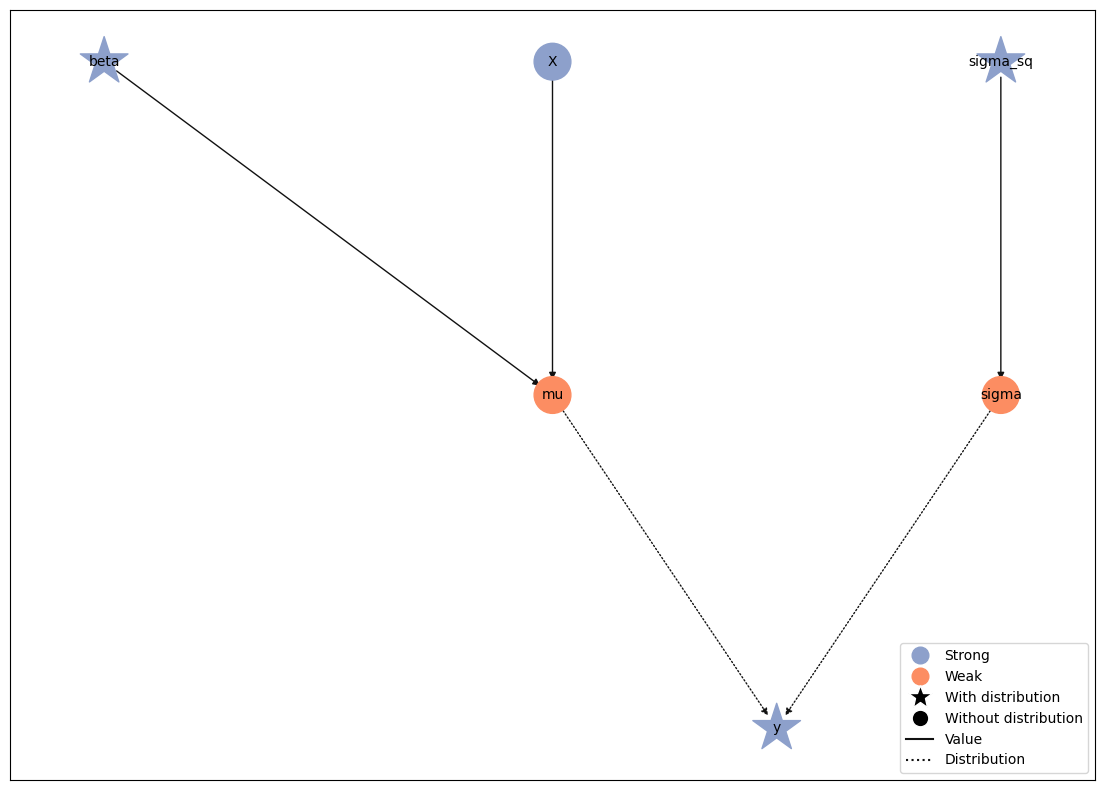

In [4]:
model.plot()

## Run the chains

In [5]:
results = gs.LieselMCMC(model).run_for_epochs(
    seed=1,
    num_chains=4,
    adaptation=1000,
    posterior=1000,
    show_progress=False,
)

summary = gs.Summary(results)

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


In [6]:
summary.to_dataframe().set_index("var_fqn")[
    ["mean", "sd", "q_0.05", "q_0.95", "mcse_mean"]
].round(3)

,mean,sd,q_0.05,q_0.95,mcse_mean
var_fqn,,,,,
beta[0],0.983,0.091,0.836,1.130,0.003
beta[1],1.911,0.158,1.653,2.175,0.005
sigma_sq,1.039,0.066,0.936,1.152,0.001


In [7]:
summary.aggregate_diagnostics().round(3)

,ess_bulk,ess_tail,rhat,aggregated_by
parameter,,,,
beta,1054.548,1369.717,1.004,min (ess); max (rhat)
sigma_sq,3953.614,3971.327,1.001,min (ess); max (rhat)


In [8]:
summary.error_df().reset_index().filter(["error_msg", "phase", "count"])

,error_msg,phase,count
0,divergent transition,warmup,49
1,divergent transition,posterior,0


The posterior means are about 0.99 for the intercept, 1.91 for the slope,
and 1.04 for the variance, close to the generating values 1, 2, and 1.
The largest R-hat is about 1.005 and the smallest bulk ESS is about 1,100.
The NUTS update records 45 warmup divergences and none during posterior
sampling. These diagnostics support using the draws for this example;
check the chain paths as well.

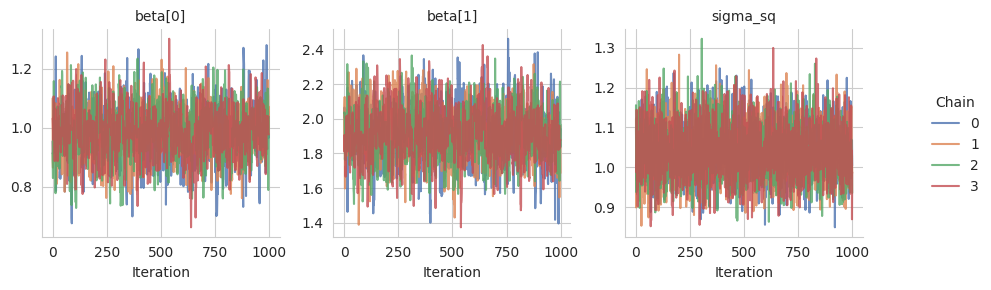

In [9]:
gs.plot_trace(results, params=["beta", "sigma_sq"])

Inspect the overlap of the chains together with ESS, R-hat, and reported errors.
An exact Gibbs draw is always accepted, but the sequence of alternating block
updates can still mix slowly. See {doc}`../../goose-diagnostics`.

## Compare with joint NUTS

Build a fresh model with the same data and priors, then transform its variance.
The repeated setup keeps both sampling strategies independent.

In [10]:
beta_joint = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, 0.0, 5.0),
    name="beta",
)
variance_joint = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.InverseGamma, concentration=3.0, scale=2.0),
    name="sigma_sq",
)

# Connect the parameters to the observations.
sigma_joint = lsl.Var.new_calc(jnp.sqrt, variance_joint, name="sigma")
X_joint = lsl.Var.new_obs(X_mat, name="X")
mu_joint = lsl.Var.new_calc(jnp.dot, X_joint, beta_joint, name="mu")
y_joint = lsl.Var.new_obs(
    y_vec,
    dist=lsl.Dist(tfd.Normal, mu_joint, sigma_joint),
    name="y",
)

# Configure a joint update on the unconstrained scale.
joint = gs.MCMCSpec(
    gs.NUTSKernel,
    kernel_group="regression",
    jitter_dist=tfd.Normal(0.0, 0.2),
)
beta_joint.inference = joint
variance_joint.biject(tfb.Exp(), name="log_sigma_sq", inference=joint)
joint_model = lsl.Model(y_joint)

In [11]:
joint_results = gs.LieselMCMC(joint_model).run_for_epochs(
    seed=1,
    num_chains=4,
    adaptation=1000,
    posterior=1000,
    positions_included=["sigma_sq"],
    show_progress=False,
)

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


Compare both methods on the original variance scale, including Monte Carlo
precision and diagnostics:

In [12]:
comparison = pd.concat(
    {
        "NUTS + Gibbs": gs.Summary(
            results, selected=["beta", "sigma_sq"]
        ).to_dataframe(),
        "Joint NUTS": gs.Summary(
            joint_results, selected=["beta", "sigma_sq"]
        ).to_dataframe(),
    },
    names=["Sampler"],
)

In [13]:
comparison.set_index("var_fqn", append=True)[
    ["mean", "sd", "mcse_mean", "ess_bulk", "rhat"]
].round(3)

mean     sd  mcse_mean  ess_bulk   rhat
Sampler      variable var_fqn                                           
NUTS + Gibbs beta     beta[0]   0.983  0.091      0.003  1054.548  1.004
                      beta[1]   1.911  0.158      0.005  1132.174  1.003
             sigma_sq sigma_sq  1.039  0.066      0.001  3953.614  1.001
Joint NUTS   beta     beta[0]   0.990  0.091      0.002  1444.217  1.004
                      beta[1]   1.899  0.158      0.004  1432.583  1.005
             sigma_sq sigma_sq  1.039  0.065      0.001  2172.744  1.003

The posterior means agree within a few thousandths in this run. Gibbs gives
more effective draws for the variance here, while joint NUTS gives more for
the coefficients. Both runs have R-hat below 1.01 for these quantities. This comparison uses two actual runs,
not stored reference values. It does not establish a universally faster
strategy: the value of blocking depends on the posterior and the cost of each
update. Inspect errors for the comparison run too:

In [14]:
gs.Summary(joint_results).error_df().reset_index().filter(
    ["error_msg", "phase", "count"]
)

,error_msg,phase,count
0,divergent transition,warmup,50
1,divergent transition,posterior,0


Next, {doc}`choose other kernels and blocks <../../goose-kernels>` or
{doc}`supply a custom Metropolis-Hastings proposal <08-custom-kernel>`.